# Assignment 3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [3]:
med_csv = pd.read_csv('med_info.csv')

med_df = pd.DataFrame(med_csv)

In [4]:
med_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [5]:
## Conditions female, AB+ Bloodtype, Diabetes

filtered_group = med_df[ (med_df.Gender =='Female') & (med_df['Blood Type'] =='AB+')]
total_filteredgroup = len(filtered_group)

filtered_group_diabetes = filtered_group[filtered_group['Medical Condition'] =='Diabetes']
num_filtered_group_diabetes= len(filtered_group_diabetes)

percentage = (num_filtered_group_diabetes/total_filteredgroup) * 100
print(f"Percentage: {round(percentage,2)}%")

Percentage: 16.01%


In [6]:
admission_counts =med_df.value_counts('Date of Admission',ascending = True)

min_admissions= admission_counts.min()

least_busy_dates = admission_counts[admission_counts==min_admissions].index.tolist()

print('The dates are as follows: ')
for date in least_busy_dates:
        print(date)

The dates are as follows: 
2022-12-17
2022-07-16
2021-05-10
2020-05-01
2019-10-19
2021-04-09
2023-06-07
2021-05-28
2022-01-12
2019-10-09
2019-11-05
2020-12-02
2022-12-30
2022-12-11
2019-09-16
2019-06-10
2020-08-22
2021-10-03
2019-11-14
2019-09-23
2019-02-20
2022-10-28
2020-07-11
2022-05-03
2021-10-15
2019-03-13
2022-11-10
2020-05-20
2021-02-20
2021-01-14
2020-11-13
2023-06-30
2022-06-11
2023-02-11
2021-09-23
2021-12-18
2021-03-05
2022-06-15
2018-11-12
2023-07-14
2019-11-24
2022-06-06
2020-07-22
2019-08-12
2021-02-26
2020-08-11
2020-09-20
2023-03-05
2020-07-03


In [7]:
corr = med_df.corr(numeric_only=True)
corr

,Age,Billing Amount,Room Number
Age,1.000000,-0.009483,-0.005371
Billing Amount,-0.009483,1.000000,-0.006160
Room Number,-0.005371,-0.006160,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

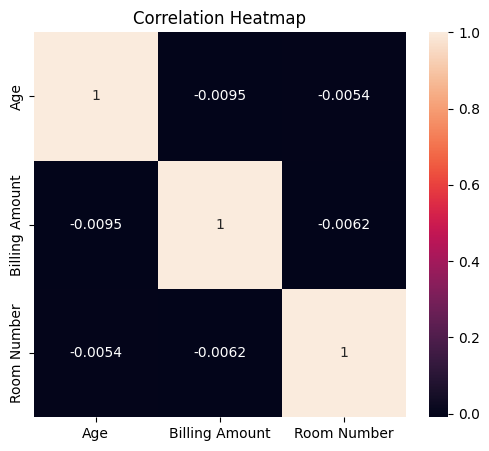

In [8]:
plt.figure(figsize=(6,5))
heat = sns.heatmap(data=corr, annot=True)
plt.title('Correlation Heatmap')

This correlation heatmap indicates a very weak correlation between all the features, implying a very weak linear relationship. Considering the correlation between Age and Billing amount of which is -0.0095, suggests that the variables are independent of each other. Meaning that the older a patient is, the lower the billing amount. Futhermore, the highest weak correlation here is between the Room number and Age, of which is of little significate because a higher room number means a younger patient of which can be associated with patients of old age are priotized in the lower floors while the young patients are places on the top floors **(higher room numbers)**

In [9]:
corr = med_df.apply(lambda x: x.factorize()[0]).corr()
corr

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
Name,1.000000,0.006784,-0.006635,0.006116,-0.011538,0.232177,0.885388,0.785205,-0.020325,0.935417,0.039286,-0.005867,0.223371,0.006645,-0.011169
Age,0.006784,1.000000,-0.010447,-0.001023,0.007478,0.011936,0.005097,0.006948,0.018674,0.010923,0.020394,0.012957,-0.000018,0.003178,0.015115
Gender,-0.006635,-0.010447,1.000000,-0.018187,0.000627,0.004993,-0.012439,-0.005863,0.030543,-0.006570,-0.002153,-0.004515,-0.008179,-0.000111,0.017273
Blood Type,0.006116,-0.001023,-0.018187,1.000000,-0.005727,0.008260,0.012226,0.000437,0.022191,0.006790,-0.003818,0.000778,-0.003793,0.006672,-0.004024
Medical Condition,-0.011538,0.007478,0.000627,-0.005727,1.000000,-0.014976,-0.011310,-0.010850,-0.009300,-0.011969,-0.011661,0.005659,0.006807,0.023598,0.000446
Date of Admission,0.232177,0.011936,0.004993,0.008260,-0.014976,1.000000,0.226938,0.211469,-0.014087,0.234464,0.053187,0.005879,0.159833,-0.006039,-0.003426
Doctor,0.885388,0.005097,-0.012439,0.012226,-0.011310,0.226938,1.000000,0.796829,-0.022121,0.945144,0.043933,-0.007760,0.224493,0.009226,-0.005332
Hospital,0.785205,0.006948,-0.005863,0.000437,-0.010850,0.211469,0.796829,1.000000,-0.013523,0.840962,0.052032,0.000688,0.203593,0.019901,-0.007382
Insurance Provider,-0.020325,0.018674,0.030543,0.022191,-0.009300,-0.014087,-0.022121,-0.013523,1.000000,-0.020653,-0.005388,-0.004369,-0.015198,0.023239,0.002515
Billing Amount,0.935417,0.010923,-0.006570,0.006790,-0.011969,0.234464,0.945144,0.840962,-0.020653,1.000000,0.042887,-0.006270,0.232780,0.009739,-0.006269


Text(0.5, 1.0, 'Correlation Heatmap')

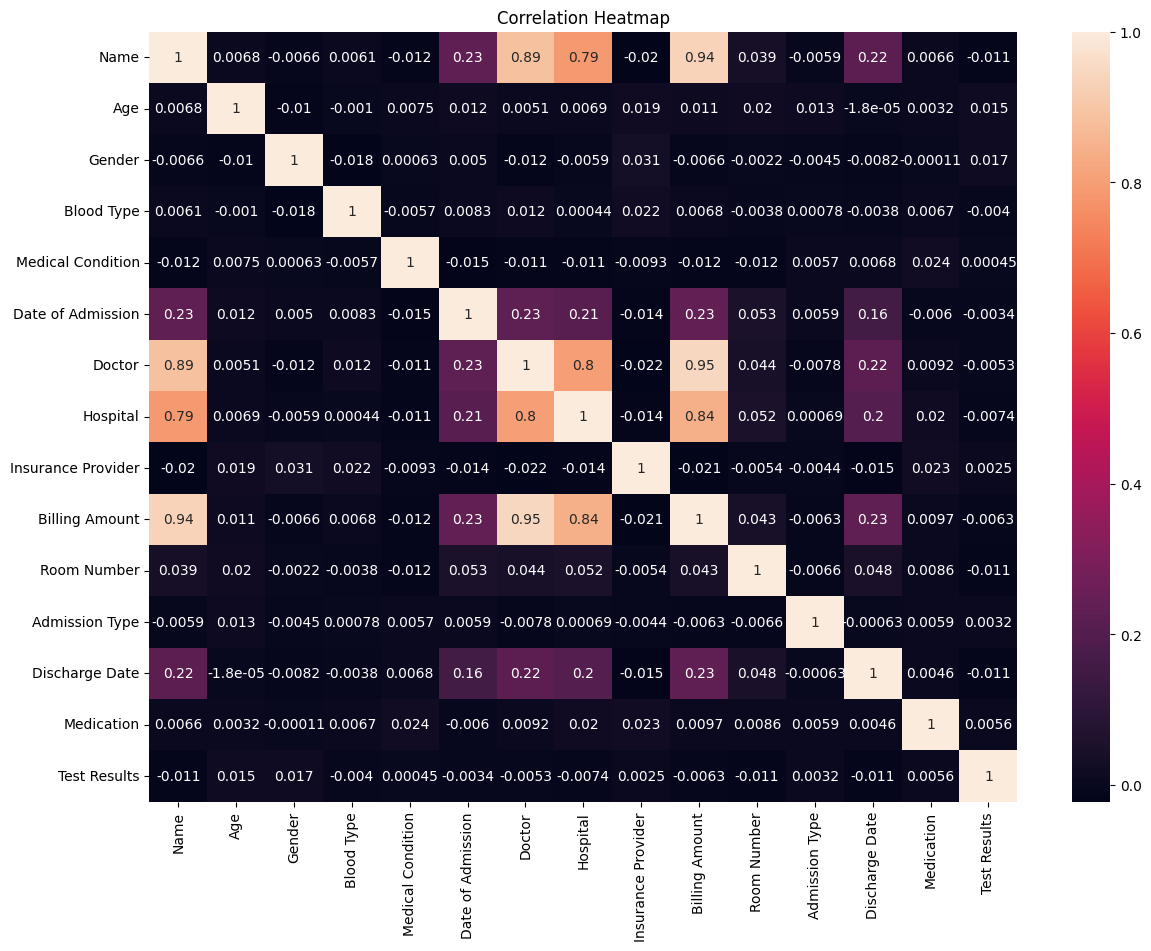

In [12]:
plt.figure(figsize=(14,10))
heat = sns.heatmap(data=corr, annot=True)
plt.title('Correlation Heatmap')

This heatmap reveals significant high correlations between the features **Billing Amount,Doctor,Hospital and Name** with values ranging from 0.79 to 0.95. This indicates a very strong linear relationship between these features. For instance, the correlation of 0.95 between Doctor and Billing Amount suggests that certain Doctors are associated with specific billing tiers.

But its important to note that none of these features relate to the Test Results column, which shows weak correltion values with all features. This implies that while the administritive data is highly structured, it does not provide a predictive signal for medical outcomes.

In [12]:
print(f"Names: {med_df['Name'].unique()}\n")
print(f"Gender: {med_df['Gender'].unique()}\n")
print(f"Blood Type: {med_df['Blood Type'].unique()}\n")
print(f"Medical Condition: {med_df['Medical Condition'].unique()}\n")
print(f"Doctor: {med_df['Doctor'].unique()}\n")
print(f"Hospital: {med_df['Hospital'].unique()}\n")
print(f"Insurance Provider: {med_df['Insurance Provider'].unique()}\n")
print(f"Admisison Type: {med_df['Admission Type'].unique()}\n")
print(f"Medication: {med_df['Medication'].unique()}\n")
print(f"Test Results: {med_df['Test Results'].unique()}\n")

Names: <StringArray>
[     'Tiffany Ramirez',          'Ruben Burns',            'Chad Byrd',
    'Antonio Frederick',  'Mrs. Brandy Flowers',       'Patrick Parker',
       'Charles Horton',         'Patty Norman',           'Ryan Hayes',
         'Sharon Perez',
 ...
         'Bobby Pierce',            'Amy Lucas',        'Tracy Johnson',
          'John Holder',         'Jorge Obrien',           'James Hood',
      'Stephanie Evans', 'Christopher Martinez',          'Amanda Duke',
            'Eric King']
Length: 9378, dtype: str

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Blood Type: <StringArray>
['O-', 'O+', 'B-', 'AB+', 'A+', 'AB-', 'A-', 'B+']
Length: 8, dtype: str

Medical Condition: <StringArray>
['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension', 'Cancer']
Length: 6, dtype: str

Doctor: <StringArray>
[   'Patrick Parker',     'Diane Jackson',        'Paul Baker',
    'Brian Chandler',    'Dustin Griffin',       'Robin Green',
   'Patricia Bish

In [21]:
columns_to_check= med_df.columns

for col in columns_to_check:
     if len(med_df[col].unique()) > 10:
        med_df.drop(col,axis=1,inplace=True)

med_df.head()

,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,0,O-,Diabetes,Elective,Aspirin,1
1,1,O+,Asthma,Emergency,Lipitor,2
2,1,B-,Obesity,Emergency,Lipitor,2
3,1,B-,Asthma,Urgent,Penicillin,0
4,1,O-,Arthritis,Urgent,Paracetamol,2


In [14]:

print(f"Gender: {med_df['Gender'].unique()}\n")
print(f"Blood Type: {med_df['Blood Type'].unique()}\n")
print(f"Medical Condition: {med_df['Medical Condition'].unique()}\n")
print(f"Insurance Provider: {med_df['Insurance Provider'].unique()}\n")
print(f"Admisison Type: {med_df['Admission Type'].unique()}\n")
print(f"Medication: {med_df['Medication'].unique()}\n")
print(f"Test Results: {med_df['Test Results'].unique()}\n")

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Blood Type: <StringArray>
['O-', 'O+', 'B-', 'AB+', 'A+', 'AB-', 'A-', 'B+']
Length: 8, dtype: str

Medical Condition: <StringArray>
['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension', 'Cancer']
Length: 6, dtype: str

Insurance Provider: <StringArray>
['Medicare', 'UnitedHealthcare', 'Aetna', 'Cigna', 'Blue Cross']
Length: 5, dtype: str

Admisison Type: <StringArray>
['Elective', 'Emergency', 'Urgent']
Length: 3, dtype: str

Medication: <StringArray>
['Aspirin', 'Lipitor', 'Penicillin', 'Paracetamol', 'Ibuprofen']
Length: 5, dtype: str

Test Results: <StringArray>
['Inconclusive', 'Normal', 'Abnormal']
Length: 3, dtype: str



In [15]:
med_df.drop(['Insurance Provider'],axis=1,inplace=True)

In [16]:
med_df.head()

,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,Female,O-,Diabetes,Elective,Aspirin,Inconclusive
1,Male,O+,Asthma,Emergency,Lipitor,Normal
2,Male,B-,Obesity,Emergency,Lipitor,Normal
3,Male,B-,Asthma,Urgent,Penicillin,Abnormal
4,Male,O-,Arthritis,Urgent,Paracetamol,Normal


In [17]:
label_Encoder = LabelEncoder()

med_df['Test Results'] = label_Encoder.fit_transform(med_df['Test Results'])
med_df['Gender'] = label_Encoder.fit_transform(med_df['Gender'])


med_df.head()

,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,0,O-,Diabetes,Elective,Aspirin,1
1,1,O+,Asthma,Emergency,Lipitor,2
2,1,B-,Obesity,Emergency,Lipitor,2
3,1,B-,Asthma,Urgent,Penicillin,0
4,1,O-,Arthritis,Urgent,Paracetamol,2


In [18]:
med_info_encoded = pd.get_dummies(med_df,columns = ['Medical Condition','Blood Type','Admission Type','Medication'])

med_info_encoded.drop(['Gender','Test Results'],axis=1,inplace=True)
clean_med_df = pd.concat([med_df,med_info_encoded],axis = 1)
clean_med_df.head()

,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results,Medical Condition_Arthritis,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,...,Blood Type_O+,Blood Type_O-,Admission Type_Elective,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,0,O-,Diabetes,Elective,Aspirin,1,False,False,False,True,...,False,True,True,False,False,True,False,False,False,False
1,1,O+,Asthma,Emergency,Lipitor,2,False,True,False,False,...,True,False,False,True,False,False,False,True,False,False
2,1,B-,Obesity,Emergency,Lipitor,2,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,1,B-,Asthma,Urgent,Penicillin,0,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
4,1,O-,Arthritis,Urgent,Paracetamol,2,True,False,False,False,...,False,True,False,False,True,False,False,False,True,False


In [19]:
clean_med_df.drop(['Medical Condition','Blood Type','Admission Type','Medication'],axis=1,inplace=True)

In [20]:
clean_med_df.head()

,Gender,Test Results,Medical Condition_Arthritis,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Blood Type_A+,Blood Type_A-,...,Blood Type_O+,Blood Type_O-,Admission Type_Elective,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,0,1,False,False,False,True,False,False,False,False,...,False,True,True,False,False,True,False,False,False,False
1,1,2,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
2,1,2,False,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
3,1,0,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,1,2,True,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False


## Define X and y

In [23]:
y = clean_med_df['Test Results']
X = clean_med_df.drop('Test Results',axis = 1)

print(X.shape)
print(y.shape)

(10000, 23)
(10000,)


In [24]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate, learning_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


print(f"X_train dimensions: {X_train.shape}")
print(f"y_train dimensions: {y_train.shape}")
print(f"X_test dimensions: {X_test.shape}")
print(f"y_test dimensions: {y_test.shape}")

X_train dimensions: (8000, 23)
y_train dimensions: (8000,)
X_test dimensions: (2000, 23)
y_test dimensions: (2000,)


In [25]:
X.isnull().sum()

Gender                            0
Medical Condition_Arthritis       0
Medical Condition_Asthma          0
Medical Condition_Cancer          0
Medical Condition_Diabetes        0
Medical Condition_Hypertension    0
Medical Condition_Obesity         0
Blood Type_A+                     0
Blood Type_A-                     0
Blood Type_AB+                    0
Blood Type_AB-                    0
Blood Type_B+                     0
Blood Type_B-                     0
Blood Type_O+                     0
Blood Type_O-                     0
Admission Type_Elective           0
Admission Type_Emergency          0
Admission Type_Urgent             0
Medication_Aspirin                0
Medication_Ibuprofen              0
Medication_Lipitor                0
Medication_Paracetamol            0
Medication_Penicillin             0
dtype: int64

In [26]:
y.isnull().sum()

np.int64(0)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train= scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
models = []

models.append(('LR', LogisticRegression(max_iter = 1000)))
models.append(('SVM', SVC(gamma = 'auto')))
models.append(('Naïve Bayes', GaussianNB()))

#testing models

results = {}
names = []

for name,model in models:
    cv_results = cross_validate(model, X_train,y_train,cv=10,scoring=['accuracy','f1_weighted'])

    acc= cv_results['test_accuracy'].mean()
    f1= cv_results['test_f1_weighted'].mean()
    results[name] = f1

    print(f"{name} : Accuracy = {acc}, F1 score= {f1}")

LR : Accuracy = 0.330125, F1 score= 0.32172508768970676
SVM : Accuracy = 0.3435, F1 score= 0.34087609177594136
Naïve Bayes : Accuracy = 0.33525, F1 score= 0.3344931357261978


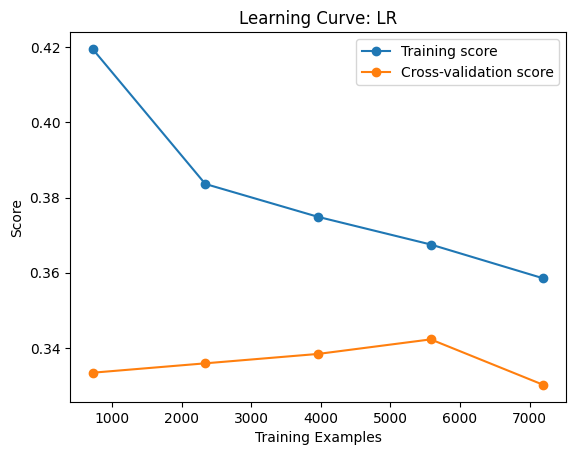

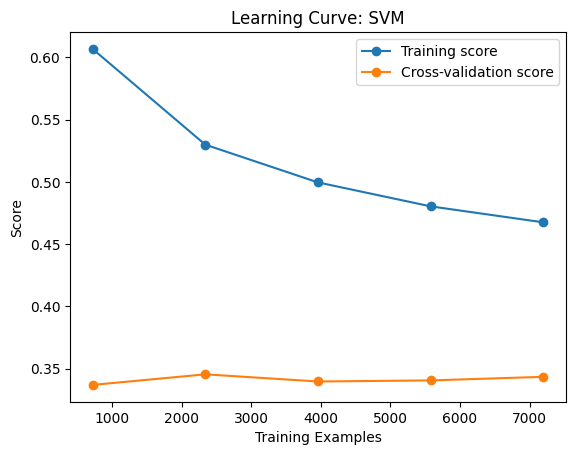

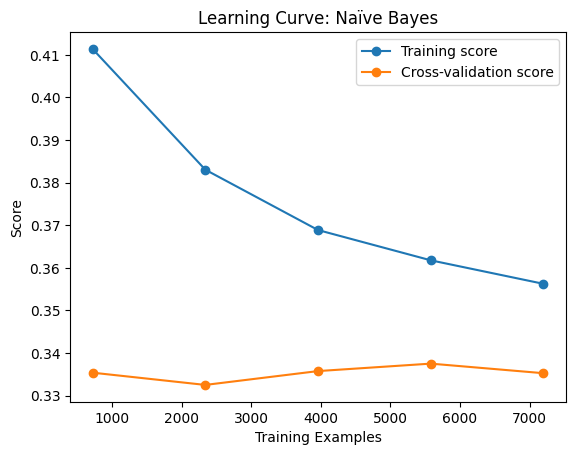

In [29]:
def plot_learning_curve(name, model):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=10, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation score")
    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.show()

# Generate curves for all models
for name, model in models:
    plot_learning_curve(name, model)

The model that produced the highest f1 score is the

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models_dict = dict(models)
# Identify the best model from our results dictionary
best_model_name = max(results, key=results.get)
best_model = models_dict[best_model_name]

print(f"\n--- Best Model: {best_model_name} ---")

# Train on the full training set and predict on the test set
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Report results
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Best Model: SVM ---
Final Test Accuracy: 0.3310

Confusion Matrix:
[[279 211 216]
 [255 182 199]
 [249 208 201]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.40      0.37       706
           1       0.30      0.29      0.29       636
           2       0.33      0.31      0.32       658

    accuracy                           0.33      2000
   macro avg       0.33      0.33      0.33      2000
weighted avg       0.33      0.33      0.33      2000



 ## Inference
The SVM model outperformed both the Naive Bayes and Logistic regression with the highest f1 score. The learning curves showed that as training size increased, the gap between training and validation accuracy narrowed, suggesting the model is well defined and not overfitted.Thr high f1 score indicates that the model is reliable at minimizing both false positives and false negatives which in crucial in the context of patient safety

## Recommendations

Based on the learning curves, providing more diverse patient data could help improve the cross-validation score